# Ingeniería inversa: Proyección de producción por variedades

Investigación read-only del proceso funcional **Proyección Variedades** y del **Informe Proyección Variedad** en `WF_Gaitana`.

> Seguridad: este notebook no ejecuta `Siembra.ProyeccionCalcula` ni ningún procedimiento de generación. Solo usa `SELECT`, metadata y definiciones SQL.

## Contexto previo utilizado

Se leyó `contexto_sql_gaitana_codex.txt`. Se conservan sus hallazgos: `Siembra.SiembraCama` conecta ubicación y siembra; `TablasBasicas.Variedad`/`Producto` describen el producto; `CicloVariedad → CurvaCiclo → CurvaCoeficiente` contiene la configuración; `Siembra.ProyeccionSemana` es el resultado base; y los agregados conocidos son `ProyInvernaVariedad`, `ProyFincaVariedad` y `ProyeccionGrado`.

La fórmula documentada previamente para el método por edad es `ROUND(Area * Coeficiente, 0)` cuando `PickForma = 44`, y `ROUND(Planta * Coeficiente, 0)` en los demás casos. `CurvaCoeficiente.SemanaDia` es edad; `ProyeccionSemana.SemanaProyeccion` es semana calendario.

Los resultados de esta sesión se separan en hechos, inferencias e hipótesis.

## Cómo leer este notebook

Lee las secciones en orden. Cada etapa responde una pregunta distinta:

1. **Qué objetos existen:** catálogo, columnas y dependencias.
2. **Cómo se calcula:** definición de `Siembra.ProyeccionCalcula` y sus inputs.
3. **Dónde queda el resultado:** `Siembra.ProyeccionSemana` y sus agregados.
4. **Cómo lo muestra el informe:** `Siembra.ProyeccionSemanaView` y procedimientos del esquema `Reporte`.
5. **Qué histórico existe:** tablas de histórico y significado de `FechaAuditoria`.
6. **Cómo extraerlo:** consulta de muestra y consulta completa.

### Lectura rápida del proceso

`Siembra.SiembraCama` aporta qué se sembró y dónde. Las tablas de ciclo y curvas aportan el coeficiente productivo. `Siembra.ProyeccionCalcula` transforma esos inputs en filas de `Siembra.ProyeccionSemana`. `Siembra.ProyeccionSemanaView` enriquece esas filas con nombres de finca, invernadero, producto y variedad. Los procedimientos del esquema `Reporte` consultan esa vista para presentar el informe.

### Convención de evidencia

- **HECHO CONFIRMADO:** aparece en datos, metadata o definición SQL.
- **INFERENCIA:** explicación razonable derivada de varios hechos.
- **HIPÓTESIS/PENDIENTE:** requiere revisar otra capa o no está demostrado.

Las celdas que comienzan con `q_` construyen SQL. Las celdas que llaman `run_readonly(...)` ejecutan únicamente consultas `SELECT`/`WITH`.

## Resumen ejecutivo antes de entrar al detalle

La evidencia encontrada indica que el informe de proyección por variedad no calcula nuevamente la producción: lee resultados ya almacenados. El camino confirmado es:

`Siembra.SiembraCama + configuración productiva → Siembra.ProyeccionCalcula → Siembra.ProyeccionSemana → Siembra.ProyeccionSemanaView → Reporte.InformeProyeccionSemana`

También existe `Reporte.InformeDeProyeccionesPorVariedadSemana`, que agrupa la misma vista por finca, invernadero, producto, variedad y semana.

El histórico encontrado no es un snapshot global garantizado de cada ejecución: `Siembra.SiembraErradicacion` copia las proyecciones de una siembra cuando esta se erradica. Por eso `FechaAuditoria` del histórico significa momento de copia/erradicación, no necesariamente momento de generación del forecast.

In [1]:
import re
from pathlib import Path
import pandas as pd
from IPython.display import Markdown, display
import pyodbc

# Configuración de la conexión
conn_str = (
    r"DRIVER={ODBC Driver 18 for SQL Server};"
    r"SERVER=192.168.1.9;"
    r"DATABASE=WF_Gaitana;"
    r"UID=WebflorRead;"
    r"PWD=Webflor2020g;"
    r"TrustServerCertificate=yes;"
)

try:
    conn = pyodbc.connect(conn_str, timeout=10)
    cursor = conn.cursor()
    print('Conexión establecida correctamente.')
except pyodbc.Error as error:
    print(f'No fue posible establecer la conexión: {error}')
    conn = None
    cursor = None

_forbidden = re.compile(r'\b(INSERT|UPDATE|DELETE|MERGE|DROP|ALTER|TRUNCATE|EXEC|EXECUTE)\b', re.I)
_read_prefix = re.compile(r'^\s*(SELECT|WITH)\b', re.I)

def run_readonly(name, sql, params=None, show=True):
    if not _read_prefix.search(sql) or _forbidden.search(sql):
        raise ValueError(f'{name}: consulta bloqueada por política read-only')
    if conn is None:
        print(f'{name}: sin conexión; no se ejecutó nada.')
        return pd.DataFrame()
    result = pd.read_sql_query(sql, conn, params=params)
    if show:
        display(result)
    return result

Conexión establecida correctamente.


## 1. Metadata de objetos, columnas y dependencias

Buscamos por conceptos en nombres y columnas, sin asumir que el nombre funcional coincide con el nombre físico.

In [2]:
q_objetos = """
SELECT s.name AS Esquema, o.name AS Objeto, o.type_desc AS Tipo,
       o.create_date AS FechaCreacion, o.modify_date AS FechaModificacion
FROM sys.objects o JOIN sys.schemas s ON s.schema_id=o.schema_id
WHERE LOWER(o.name) LIKE '%proy%' OR LOWER(o.name) LIKE '%varied%'
   OR LOWER(o.name) LIKE '%producc%' OR LOWER(o.name) LIKE '%productiv%'
   OR LOWER(o.name) LIKE '%indice%' OR LOWER(o.name) LIKE '%semana%'
ORDER BY o.type_desc,s.name,o.name;
"""
objetos = run_readonly('objetos candidatos', q_objetos)

q_columnas = """
SELECT s.name AS Esquema, o.name AS Objeto, o.type_desc AS Tipo,
       c.column_id, c.name AS Columna, TYPE_NAME(c.user_type_id) AS TipoDato,
       c.is_nullable, c.is_identity
FROM sys.columns c JOIN sys.objects o ON o.object_id=c.object_id
JOIN sys.schemas s ON s.schema_id=o.schema_id
WHERE LOWER(c.name) LIKE '%proy%' OR LOWER(c.name) LIKE '%productiv%'
   OR LOWER(c.name) LIKE '%indice%' OR LOWER(c.name) LIKE '%semana%'
   OR LOWER(c.name) LIKE '%gener%' OR LOWER(c.name) LIKE '%version%'
   OR LOWER(c.name) LIKE '%fecha%' OR LOWER(c.name) LIKE '%usuario%'
ORDER BY s.name,o.name,c.column_id;
"""
columnas = run_readonly('columnas candidatas', q_columnas)

q_dependencias = """
SELECT OBJECT_SCHEMA_NAME(referencing_id) AS EsquemaReferenciador,
       OBJECT_NAME(referencing_id) AS ObjetoReferenciador,
       referenced_schema_name AS EsquemaReferenciado,
       referenced_entity_name AS ObjetoReferenciado
FROM sys.sql_expression_dependencies
WHERE OBJECT_NAME(referencing_id) LIKE '%Proy%'
   OR referenced_entity_name LIKE '%Proy%';
"""
dependencias = run_readonly('dependencias', q_dependencias)

C:\Users\elian\AppData\Local\Temp\ipykernel_48724\4200763431.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(sql, conn, params=params)


,Esquema,Objeto,Tipo,FechaCreacion,FechaModificacion
0,Inventario,DF_ConsumoSemanaActual,DEFAULT_CONSTRAINT,2020-07-13 21:09:17.980,2020-07-13 21:09:17.980
1,Inventario,DF_ConsumoSemanaActual1,DEFAULT_CONSTRAINT,2020-09-22 06:02:51.413,2020-09-22 06:02:51.413
2,Inventario,DF_ConsumoSemanaSiguiente,DEFAULT_CONSTRAINT,2020-07-13 21:09:17.973,2020-07-13 21:09:17.973
3,Inventario,DF_ConsumoSemanaSiguiente1,DEFAULT_CONSTRAINT,2020-09-22 06:02:51.413,2020-09-22 06:02:51.413
4,Inventario,DF_CorteSemanaActual,DEFAULT_CONSTRAINT,2020-07-13 21:09:17.980,2020-07-13 21:09:17.980
...,...,...,...,...,...
248,Siembra,ProyeccionSemanaView,VIEW,2018-10-17 10:11:45.830,2023-11-29 07:37:33.430
249,Siembra,SemanaDelAnioView,VIEW,2020-03-26 06:37:38.467,2023-11-29 07:37:37.930
250,Siembra,SiembraVariedadView,VIEW,2018-10-17 10:11:45.807,2023-11-29 07:37:33.010
251,TablasBasicas,CicloVariedadView,VIEW,2018-10-17 10:11:45.820,2023-11-29 07:37:31.190


C:\Users\elian\AppData\Local\Temp\ipykernel_48724\4200763431.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(sql, conn, params=params)


,Esquema,Objeto,Tipo,column_id,Columna,TipoDato,is_nullable,is_identity
0,Auditoria,ClasificacionVariedadAudit,USER_TABLE,17,IdUsuarioAuditoria,int,False,False
1,Auditoria,ClasificacionVariedadAudit,USER_TABLE,18,FechaClasificacion,datetime,False,False
2,Auditoria,ClasificacionVariedadAudit,USER_TABLE,19,FechaAuditoria,datetime,False,False
3,Auditoria,ClasificacionVariedadAudit,USER_TABLE,23,Semana,int,True,False
4,Auditoria,ClasificacionVariedadAudit,USER_TABLE,34,FechaGeneraEtiqueta,datetime,True,False
...,...,...,...,...,...,...,...,...
1180,Venta,PreOrdenRecetaDetalle,USER_TABLE,19,FechaCreacion,datetime,True,False
1181,Venta,PreOrdenRecetaDetalleOpcionales,USER_TABLE,14,FechaAuditoria,datetime,False,False
1182,Venta,PreOrdenRecetaDetalleOpcionales,USER_TABLE,15,IdUsuarioAuditoria,int,False,False
1183,Venta,TMPEmpaque,USER_TABLE,12,IdUsuarioAuditoria,int,False,False


C:\Users\elian\AppData\Local\Temp\ipykernel_48724\4200763431.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(sql, conn, params=params)


,EsquemaReferenciador,ObjetoReferenciador,EsquemaReferenciado,ObjetoReferenciado
0,Siembra,ProyeccionCalcula,siembra,Calcular_Fecha
1,Siembra,ProyeccionCalcula1,siembra,Calcular_Fecha
2,Siembra,ProyeccionCalcula,Siembra,CalcularAnio
3,Siembra,ProyeccionCalcula1,Siembra,CalcularAnio
4,Reporte,InformeClasificacionProyeccionANT,Siembra,CalcularSemana
...,...,...,...,...
148,Siembra,ProyeccionCalculaProducto,TablasBasicas,Variedad
149,Siembra,ProyeccionCalcula,TablasBasicas,Variedad
150,Siembra,ProyeccionCalcula1,TablasBasicas,Variedad
151,Reporte,InformeComparativoYProyeccion,TablasBasicas,VariedadView


## 2. Objetos relevantes encontrados

La metadata real mostró estos objetos relevantes:

- Cálculo: `Siembra.ProyeccionCalcula`.
- Resultado base: `Siembra.ProyeccionSemana` y `Siembra.ProyeccionSemanaView`.
- Agregados: `Siembra.ProyFincaVariedad`, `Siembra.ProyInvernaVariedad`, `Siembra.ProyeccionGrado`.
- Informe: `Reporte.InformeProyeccionSemana` y `Reporte.InformeDeProyeccionesPorVariedadSemana`.
- Productividad: `Mapa.ListInvIndicesProductividad`, `Siembra.SiembrasIndicesProductividadToExcel`, `Siembra.CurvasDeProductividad`, `Siembra.CicloVariCoefInverna` y `Siembra.CicloVariCoefFinca`.
- Histórico: `Siembra.HistoricoProyeccionSemana`, `Siembra.HistoricoProyeccionDia` y `Siembra.ProyeccionLog`.

**Hecho confirmado:** existe un histórico físico. **Todavía no significa** que sea un snapshot de cada ejecución; la semántica se valida en la definición de `Siembra.SiembraErradicacion`.

## 3. Definiciones SQL: calcular, informar y productividad

Se leen las definiciones desde `sys.sql_modules`. No se usa `EXEC`, por lo que el procedimiento de cálculo no se ejecuta.

In [3]:
q_definiciones = """
SELECT s.name AS Esquema, o.name AS Objeto, o.type_desc AS Tipo, m.definition AS DefinicionSQL
FROM sys.sql_modules m JOIN sys.objects o ON o.object_id=m.object_id
JOIN sys.schemas s ON s.schema_id=o.schema_id
WHERE (s.name='Siembra' AND o.name IN ('ProyeccionCalcula','ProyeccionAjuste',
       'ProyeccionSemanaVarListar','ProyeccionSemanaInvListar',
       'SiembrasIndicesProductividadToExcel','CurvasDeProductividad'))
   OR (s.name='Reporte' AND o.name IN ('InformeProyeccionSemana',
       'InformeProyeccionDia','InformeDeProyeccionesPorVariedadSemana'))
   OR (s.name='Mapa' AND o.name='ListInvIndicesProductividad');
"""
definiciones = run_readonly('definiciones SQL', q_definiciones, show=False)
display(definiciones[['Esquema','Objeto','Tipo']] if not definiciones.empty else definiciones)
def mostrar_definicion(esquema, objeto, solo_lineas_clave=False):
    seleccion = definiciones[(definiciones['Esquema'] == esquema) & (definiciones['Objeto'] == objeto)]
    if seleccion.empty:
        print(f'No se encontró {esquema}.{objeto} o no hay permisos de definición.')
        return
    definicion = seleccion.iloc[0]['DefinicionSQL'] or ''
    if solo_lineas_clave:
        lineas = definicion.splitlines()
        patrones = ('FROM ', 'JOIN ', 'INSERT ', 'UPDATE ', 'DELETE ', 'TRUNCATE ', 'ROUND', 'Coeficiente', 'SemanaProyeccion', 'FechaAuditoria')
        lineas = [linea for linea in lineas if any(p.lower() in linea.lower() for p in patrones)]
        print('\n'.join(lineas))
    else:
        display(Markdown(f'```sql\n{definicion}\n```'))

# Primero muestra solo lo esencial para seguir el razonamiento.
mostrar_definicion('Reporte', 'InformeProyeccionSemana', solo_lineas_clave=True)
mostrar_definicion('Reporte', 'InformeDeProyeccionesPorVariedadSemana', solo_lineas_clave=True)
mostrar_definicion('Siembra', 'ProyeccionCalcula', solo_lineas_clave=True)

# Para consultar el texto completo de un objeto específico, usa por ejemplo:
# mostrar_definicion('Siembra', 'ProyeccionCalcula')

C:\Users\elian\AppData\Local\Temp\ipykernel_48724\4200763431.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(sql, conn, params=params)


,Esquema,Objeto,Tipo
0,Mapa,ListInvIndicesProductividad,SQL_STORED_PROCEDURE
1,Reporte,InformeDeProyeccionesPorVariedadSemana,SQL_STORED_PROCEDURE
2,Reporte,InformeProyeccionDia,SQL_STORED_PROCEDURE
3,Reporte,InformeProyeccionSemana,SQL_STORED_PROCEDURE
4,Siembra,CurvasDeProductividad,SQL_STORED_PROCEDURE
5,Siembra,ProyeccionAjuste,SQL_STORED_PROCEDURE
6,Siembra,ProyeccionCalcula,SQL_STORED_PROCEDURE
7,Siembra,ProyeccionSemanaInvListar,SQL_STORED_PROCEDURE
8,Siembra,ProyeccionSemanaVarListar,SQL_STORED_PROCEDURE
9,Siembra,SiembrasIndicesProductividadToExcel,SQL_STORED_PROCEDURE


    select AnioProyeccion,SemanaProyeccion,Coeficiente,ProyeccionInicial,ProyeccionFinal,IdSiembra,NumeroSiembra,IdVariedad,IdCicloVariedad,IDCurvaCiclo,
	from Siembra.ProyeccionSemanaView
	where AnioProyeccion = @Anio and SemanaProyeccion between @SemanaInicial and @SemanaFinal
select NomCompania,NomFinca,CodigoInvernadero,NomInvernadero,NomSector,NomProducto,nomcolor,NomVariedad,SemanaProyeccion,AnioProyeccion,
from [Siembra].[ProyeccionSemanaView]
Where AnioProyeccion between @vAnioInicio and @vAnioFin and SemanaProyeccion between @vSemanaInicio and @vSemanaFin
Group By NomFinca,NomInvernadero,NomProducto,NomVariedad,SemanaProyeccion,NomCompania,NomSector,nomcolor,AnioProyeccion,CodigoInvernadero
-- Diferenciar la proyeccion entre la de por Coeficiente por variedad invernadero ,Coeficiente por variedad finca
	  Coeficiente numeric(10,4),
	  Coeficiente numeric(10,4),
	  SemanaProyeccion int,
	insert into #SiembraProy (IdSiembra,IdFinca,IdInvernadero,IdVariedad,IdCicloVariedad,PickFo

### Evidencia interpretada de las definiciones

- `Reporte.InformeProyeccionSemana(@Anio, @SemanaInicial, @SemanaFinal)` hace `SELECT` sobre `Siembra.ProyeccionSemanaView` y devuelve semana, coeficiente, proyección inicial/final, siembra, variedad, finca, invernadero, ciclo, curva y dimensiones.
- `Reporte.InformeDeProyeccionesPorVariedadSemana(@FechaInicial, @FechaFinal)` convierte fechas a año/semana mediante `Siembra.CalcularSemana`, consulta la misma vista y agrega `SUM(ProyeccionInicial)` como `Proyectado` y `SUM(ProyeccionFinal)` como `Estimado`.
- `Siembra.ProyeccionSemanaView` une `Siembra.ProyeccionSemana` con `Siembra.SiembraCamaView` y `Mapa.InvernaderoView`. Esta es la ruta confirmada del informe semanal.
- `Mapa.ListInvIndicesProductividad` lista invernaderos activos con una variedad sembrada; no calcula la proyección.
- `Siembra.SiembrasIndicesProductividadToExcel` construye índices con `CurvaCoeficiente` para tipo 17, `CicloVariCoefInverna` para tipo 11 y `CicloVariCoefFinca` para tipo 12. Su definición crea tablas temporales e inserta datos, por eso no se ejecuta.
- `Siembra.ProyeccionCalcula` contiene `TRUNCATE` de tablas temporales y `DELETE` de resultados actuales antes de insertar/recalcular; analizar su definición confirma que no debe ejecutarse.

## 4. Índices de productividad e inputs

La hipótesis funcional sí tiene objetos físicos relacionados, pero no una única tabla llamada Índices de Productividad. La fuente depende del `PickTipoProyeccion`: edad/curva (17), invernadero (11) o finca (12).

In [4]:
q_inputs = """
SELECT TOP (200) sc.IdSiembra,sc.FechaSiembra,sc.AnioSiembra,sc.SemanaSiembra,
       sc.IdVariedad,v.NomVariedad,p.NomProducto,sc.IdCicloVariedad,sc.IdCurvaCiclo,
       sc.Area,sc.Planta,sc.Densidad,ccf.SemanaDia AS EdadSemana,ccf.Coeficiente,
       cv.SemanaInicioCorte,cv.SemanaPicoCorte,cv.SemanaFinCorte,cc.NomCurva
FROM Siembra.SiembraCama sc
LEFT JOIN TablasBasicas.Variedad v ON v.IdVariedad=sc.IdVariedad
LEFT JOIN TablasBasicas.Producto p ON p.IdProducto=v.IdProducto
LEFT JOIN TablasBasicas.CicloVariedad cv ON cv.IdCicloVariedad=sc.IdCicloVariedad
LEFT JOIN Siembra.CurvaCiclo cc ON cc.IdCurvaCiclo=sc.IdCurvaCiclo
LEFT JOIN Siembra.CurvaCoeficiente ccf ON ccf.IdCurvaCiclo=sc.IdCurvaCiclo
ORDER BY sc.FechaSiembra DESC,sc.IdSiembra,ccf.SemanaDia;
"""
inputs = run_readonly('inputs y curvas', q_inputs)
coef_inverna = run_readonly('coeficientes por invernadero', 'SELECT TOP (100) * FROM Siembra.CicloVariCoefInverna;')
coef_finca = run_readonly('coeficientes por finca', 'SELECT TOP (100) * FROM Siembra.CicloVariCoefFinca;')
porcentaje_grado = run_readonly('porcentajes por grado', 'SELECT TOP (100) * FROM Siembra.PorcentajeGrado ORDER BY FechaAuditoria DESC,IdPorcentajeGrado DESC;')

C:\Users\elian\AppData\Local\Temp\ipykernel_48724\4200763431.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(sql, conn, params=params)


,IdSiembra,FechaSiembra,AnioSiembra,SemanaSiembra,IdVariedad,NomVariedad,NomProducto,IdCicloVariedad,IdCurvaCiclo,Area,Planta,Densidad,EdadSemana,Coeficiente,SemanaInicioCorte,SemanaPicoCorte,SemanaFinCorte,NomCurva
0,115594,2026-09-11,2026,37,1149,Skyler White,Veronica,142,106,18.6,880,1.0,17,0.0000,17,17,30,Curva C1
1,115594,2026-09-11,2026,37,1149,Skyler White,Veronica,142,106,18.6,880,1.0,18,0.0000,17,17,30,Curva C1
2,115594,2026-09-11,2026,37,1149,Skyler White,Veronica,142,106,18.6,880,1.0,19,0.0000,17,17,30,Curva C1
3,115594,2026-09-11,2026,37,1149,Skyler White,Veronica,142,106,18.6,880,1.0,20,0.0000,17,17,30,Curva C1
4,115594,2026-09-11,2026,37,1149,Skyler White,Veronica,142,106,18.6,880,1.0,21,0.0000,17,17,30,Curva C1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,115529,2026-09-09,2026,37,6381,Crimea,Carnation,7729,7441,15.0,612,1.0,38,0.0838,18,29,104,CURVA 2
196,115529,2026-09-09,2026,37,6381,Crimea,Carnation,7729,7441,15.0,612,1.0,39,0.0713,18,29,104,CURVA 2
197,115529,2026-09-09,2026,37,6381,Crimea,Carnation,7729,7441,15.0,612,1.0,40,0.0735,18,29,104,CURVA 2
198,115529,2026-09-09,2026,37,6381,Crimea,Carnation,7729,7441,15.0,612,1.0,41,0.0698,18,29,104,CURVA 2


C:\Users\elian\AppData\Local\Temp\ipykernel_48724\4200763431.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(sql, conn, params=params)


,IdCicloVariCoefInverna,IdCicloVariedad,Semana,Coeficiente,ProyeccionFinal,ProyeccionInicial,ProduccionReal,IdUsuarioAuditoria,FechaAuditoria,Anio,IdInvernadero,Estado


C:\Users\elian\AppData\Local\Temp\ipykernel_48724\4200763431.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(sql, conn, params=params)


,IdCicloVariCoefFinca,IdCicloVariedad,Semana,Coeficiente,ProyeccionFinal,ProyeccionInicial,ProduccionReal,IdUsuarioAuditoria,FechaAuditoria,Anio,Estado


C:\Users\elian\AppData\Local\Temp\ipykernel_48724\4200763431.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(sql, conn, params=params)


,IdPorcentajeGrado,IdFinca,IdVariedad,IdGrado,AnioProyeccion,Semana,Porcentaje,Lunes,Martes,Miercoles,Jueves,Viernes,Sabado,Domingo,IdUsuarioAuditoria,FechaAuditoria
0,1129,3,50,115,2019,46,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2019-11-04 21:54:30.143
1,1128,3,50,1144,2019,46,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2019-11-04 21:54:30.137
2,1127,3,50,105,2019,46,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2019-11-04 21:54:30.133
3,1126,3,50,91,2019,46,40.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,1,2019-11-04 21:54:30.130
4,1125,3,50,85,2019,46,30.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,1,2019-11-04 21:54:30.127
5,1124,3,50,72,2019,46,30.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2019-11-04 21:54:30.120
6,1123,3,47,115,2019,46,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2019-11-04 21:52:18.693
7,1122,3,47,1144,2019,46,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2019-11-04 21:52:18.690
8,1121,3,47,105,2019,46,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2019-11-04 21:52:18.687
9,1120,3,47,91,2019,46,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2019-11-04 21:52:18.680


## 5. Resultado actual y última proyección existente

Sin un identificador de ejecución, la definición operativa de última proyección es el estado actual de `Siembra.ProyeccionSemana`. `AnioProyeccion` y `SemanaProyeccion` son semanas objetivo; `FechaAuditoria` es auditoría de fila y no se declara automáticamente como fecha de generación.

In [5]:
q_ultima_muestra = """
SELECT TOP (200) AnioProyeccion,SemanaProyeccion,Coeficiente,ProyeccionInicial,ProyeccionFinal,
       IdSiembra,NumeroSiembra,IdVariedad,IdCicloVariedad,IdCurvaCiclo,Area,Planta,Densidad,
       AnioSiembra,SemanaSiembra,NumeroCama,NomFinca,NomInvernadero,NomSector,NomVariedad,
       NomProducto,NomCiclo,NomCurva,nomcolor
FROM Siembra.ProyeccionSemanaView
ORDER BY AnioProyeccion DESC,SemanaProyeccion DESC,IdSiembra DESC;
"""
ultima_muestra = run_readonly('muestra última proyección', q_ultima_muestra)

q_resumen = """
SELECT COUNT_BIG(*) AS Registros,MIN(FechaAuditoria) AS PrimeraAuditoria,MAX(FechaAuditoria) AS UltimaAuditoria,
       MIN(AnioProyeccion) AS AnioMin,MAX(AnioProyeccion) AS AnioMax,
       MIN(SemanaProyeccion) AS SemanaMin,MAX(SemanaProyeccion) AS SemanaMax,
       COUNT(DISTINCT IdSiembra) AS Siembras
FROM Siembra.ProyeccionSemana;
"""
resumen = run_readonly('resumen última proyección', q_resumen)

C:\Users\elian\AppData\Local\Temp\ipykernel_48724\4200763431.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(sql, conn, params=params)


,AnioProyeccion,SemanaProyeccion,Coeficiente,ProyeccionInicial,ProyeccionFinal,IdSiembra,NumeroSiembra,IdVariedad,IdCicloVariedad,IdCurvaCiclo,...,SemanaSiembra,NumeroCama,NomFinca,NomInvernadero,NomSector,NomVariedad,NomProducto,NomCiclo,NomCurva,nomcolor
0,2026,52,0.1500,118,118,114453,167,629,940,655,...,30,167,GAITANA,Bloque 09,Elvia Romero,Kiwi Mellow Cool,Green ball,SIEMBRA,Curva C1,green
1,2026,52,0.1500,180,180,114452,165,629,940,655,...,30,165,GAITANA,Bloque 09,Elvia Romero,Kiwi Mellow Cool,Green ball,SIEMBRA,Curva C1,green
2,2026,52,0.1500,180,180,114451,166,629,940,655,...,30,166,GAITANA,Bloque 09,Elvia Romero,Kiwi Mellow Cool,Green ball,SIEMBRA,Curva C1,green
3,2026,52,0.1500,180,180,114450,163,629,940,655,...,30,163,GAITANA,Bloque 09,Elvia Romero,Kiwi Mellow Cool,Green ball,SIEMBRA,Curva C1,green
4,2026,52,0.1500,62,62,114449,164,629,940,655,...,30,164,GAITANA,Bloque 09,Elvia Romero,Kiwi Mellow Cool,Green ball,SIEMBRA,Curva C1,green
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2026,52,0.0207,25,25,114188,099,845,926,644,...,29,99,GAITANA,Bloque 04,Martha Forero,Pigeon,Minicarnation,SIEMBRA,Curva C1,hot pink
196,2026,52,0.0207,25,25,114187,097,845,926,644,...,29,97,GAITANA,Bloque 04,Martha Forero,Pigeon,Minicarnation,SIEMBRA,Curva C1,hot pink
197,2026,52,0.0207,25,25,114186,095,845,926,644,...,29,95,GAITANA,Bloque 04,Martha Forero,Pigeon,Minicarnation,SIEMBRA,Curva C1,hot pink
198,2026,52,0.0207,25,25,114185,093,845,926,644,...,29,93,GAITANA,Bloque 04,Martha Forero,Pigeon,Minicarnation,SIEMBRA,Curva C1,hot pink


C:\Users\elian\AppData\Local\Temp\ipykernel_48724\4200763431.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(sql, conn, params=params)


,Registros,PrimeraAuditoria,UltimaAuditoria,AnioMin,AnioMax,SemanaMin,SemanaMax,Siembras
0,310580,2020-10-22 08:50:45.750,2026-07-28 11:06:26.070,2020,2026,1,52,9569


### Resultado real observado

La consulta read-only devolvió para `Siembra.ProyeccionSemana`: **310.580 registros**, **9.569 siembras**, objetivos entre **2020 y 2026**, semanas **1 a 52**, auditoría entre **2020-10-22 08:50:45.750** y **2026-07-28 11:06:26.070**.

Muestra real de la semana objetivo `2026/52`:

| Finca | Bloque | Variedad | Producto | Siembra | Plantas | Coeficiente | Inicial | Final |
|---|---|---|---|---:|---:|---:|---:|---:|
| GAITANA | Bloque 09 | Kiwi Mellow Cool | Green ball | 114453 | 784 | 0.1500 | 118 | 118 |
| GAITANA | Bloque 09 | Kiwi Mellow Cool | Green ball | 114452 | 1200 | 0.1500 | 180 | 180 |
| GAITANA | Bloque 12 | Thia | Raffine | 114443 | 1000 | 0.0194 | 19 | 19 |
| GAITANA | Bloque 32 | Gio | Solomio | 114439 | 1000 | 0.0000 | 0 | 0 |

La muestra se ordena por semana objetivo; no demuestra que esas filas hayan sido generadas en una misma ejecución.

## 6. Histórico de proyecciones

El histórico existe, pero su semántica es distinta de un historial de forecasts. La definición de `Siembra.SiembraErradicacion` muestra que, al erradicar una siembra, copia sus filas actuales de `ProyeccionSemana`/`ProyeccionDia` a `HistoricoProyeccionSemana`/`HistoricoProyeccionDia` con `GETDATE()` y luego elimina las filas actuales.

In [6]:
q_historico_resumen = """
SELECT 'HistoricoSemana' AS Tabla,COUNT_BIG(*) AS Filas,MIN(FechaAuditoria) AS PrimeraAuditoria,
       MAX(FechaAuditoria) AS UltimaAuditoria,MIN(AnioProyeccion) AS AnioMin,MAX(AnioProyeccion) AS AnioMax,
       MIN(SemanaProyeccion) AS SemanaMin,MAX(SemanaProyeccion) AS SemanaMax,COUNT(DISTINCT IdSiembra) AS Siembras
FROM Siembra.HistoricoProyeccionSemana
UNION ALL
SELECT 'HistoricoDia',COUNT_BIG(*),MIN(FechaAuditoria),MAX(FechaAuditoria),MIN(AnioProyeccion),MAX(AnioProyeccion),
       MIN(SemanaProyeccion),MAX(SemanaProyeccion),COUNT(DISTINCT IdSiembra)
FROM Siembra.HistoricoProyeccionDia;
"""
historico_resumen = run_readonly('resumen histórico', q_historico_resumen)

q_historico_muestra = """
SELECT TOP (100) FechaAuditoria,IdHistoricoProyeccionSemana,IdProyeccionSemana,IdSiembra,
       AnioProyeccion,SemanaProyeccion,ProyeccionFinal,ProyeccionInicial,Coeficiente,IdUsuarioAuditoria
FROM Siembra.HistoricoProyeccionSemana
ORDER BY FechaAuditoria DESC,IdHistoricoProyeccionSemana DESC;
"""
historico_muestra = run_readonly('muestra histórica', q_historico_muestra)

C:\Users\elian\AppData\Local\Temp\ipykernel_48724\4200763431.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(sql, conn, params=params)


,Tabla,Filas,PrimeraAuditoria,UltimaAuditoria,AnioMin,AnioMax,SemanaMin,SemanaMax,Siembras
0,HistoricoSemana,1352469,2023-09-19 06:32:45.900,2026-09-19 12:06:04.287,2021,2026,1,52,25118
1,HistoricoDia,22985,2023-11-09 06:13:12.577,2025-07-28 09:27:49.563,2022,2023,1,52,1022


C:\Users\elian\AppData\Local\Temp\ipykernel_48724\4200763431.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(sql, conn, params=params)


,FechaAuditoria,IdHistoricoProyeccionSemana,IdProyeccionSemana,IdSiembra,AnioProyeccion,SemanaProyeccion,ProyeccionFinal,ProyeccionInicial,Coeficiente,IdUsuarioAuditoria
0,2026-09-19 12:06:04.287,1353117,14747576,103627,2026,29,330,330,0.3094,6134
1,2026-09-19 12:06:04.287,1353116,14747575,103627,2026,28,330,330,0.3093,6134
2,2026-09-19 12:06:04.287,1353115,14747574,103627,2026,27,252,252,0.2360,6134
3,2026-09-19 12:06:04.287,1353114,14747573,103627,2026,26,260,260,0.2437,6134
4,2026-09-19 12:06:04.287,1353113,14747572,103627,2026,25,195,195,0.1824,6134
...,...,...,...,...,...,...,...,...,...,...
95,2026-09-19 12:06:04.270,1353022,14030938,103883,2026,17,0,0,0.0000,6134
96,2026-09-19 12:06:04.270,1353021,14030937,103883,2026,16,0,0,0.0000,6134
97,2026-09-19 12:06:04.270,1353020,14030936,103883,2026,11,4,4,0.0500,6134
98,2026-09-19 12:06:04.270,1353019,14030935,103883,2026,2,53,53,0.7400,6134


### Hechos históricos confirmados

- `HistoricoProyeccionSemana`: **1.352.469 filas**, auditoría entre **2023-09-19** y **2026-09-19**, objetivos 2021–2026 y 25.118 siembras distintas.
- `HistoricoProyeccionDia`: **22.985 filas**, auditoría entre **2023-11-09** y **2025-07-28**, objetivos 2022–2023 y 1.022 siembras.
- La última muestra histórica observada tiene `FechaAuditoria = 2026-09-19 12:06:04.287`, usuario `6134`, y filas para `IdSiembra = 103627`; esto identifica una copia histórica por erradicación, no una ejecución global.
- `ProyeccionLog` existe, pero devolvió **0 filas** y solo tiene `IdProyeccionLog`, `IdVariedad` y `Descripcion`; no permite reconstruir generaciones.

**Conclusión:** WebFlor conserva históricos de proyección asociados a siembras erradicadas, pero no se confirmó un snapshot completo por cada generación de **Proyección Variedades**. No se puede usar `MAX(FechaAuditoria)` como última ejecución global.

## 7. Query completa de extracción

Esta consulta es read-only y reproduce la vista del informe con dimensiones completas. Al no existir un `IdEjecucion` confirmado, extrae el estado actual completo de `ProyeccionSemana`.

In [7]:
QUERY_DESCARGA_ULTIMA_PROYECCION = """
SELECT AnioProyeccion,SemanaProyeccion,Coeficiente,ProyeccionInicial,ProyeccionFinal,
       IdSiembra,NumeroSiembra,IdVariedad,IdCicloVariedad,IdCurvaCiclo,Area,Planta,Densidad,
       AnioSiembra,SemanaSiembra,NumeroCama,NomCompania,NomFinca,NomInvernadero,NomSector,
       NomVariedad,NomProducto,PickTipoFlor,NomCiclo,NomCurva,nomcolor,IdInvernadero,
       CodigoInvernadero,IdFinca,IdProducto,IdColor,IdCompania
FROM Siembra.ProyeccionSemanaView
ORDER BY AnioProyeccion,SemanaProyeccion,IdFinca,IdVariedad,IdSiembra;
"""

# Ejecución opcional: solo SELECT; puede devolver cientos de miles de filas.
ultima_proyeccion = run_readonly('extracción completa', QUERY_DESCARGA_ULTIMA_PROYECCION, show=False)
print('Filas extraídas:', len(ultima_proyeccion))
if not ultima_proyeccion.empty:
    display(ultima_proyeccion.head(20))
    ruta_salida = Path('ultima_proyeccion_existente.csv')
    ultima_proyeccion.to_csv(ruta_salida,index=False,encoding='utf-8-sig')
    print('CSV generado:', ruta_salida.resolve())

C:\Users\elian\AppData\Local\Temp\ipykernel_48724\4200763431.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(sql, conn, params=params)


Filas extraídas: 310580


,AnioProyeccion,SemanaProyeccion,Coeficiente,ProyeccionInicial,ProyeccionFinal,IdSiembra,NumeroSiembra,IdVariedad,IdCicloVariedad,IdCurvaCiclo,...,PickTipoFlor,NomCiclo,NomCurva,nomcolor,IdInvernadero,CodigoInvernadero,IdFinca,IdProducto,IdColor,IdCompania
0,2020,42,0.0000,0,0,48995,063,282,6851,6635,...,Novelties,SIEMBRA,Curva C1,green,2,G100,4,71,22,1
1,2020,42,0.1534,368,368,48943,011,373,6902,6662,...,Pink,SIEMBRA,Curva C1,light pink,2,G100,4,71,25,1
2,2020,42,0.0042,5,5,48983,051,435,6959,6696,...,Novelties,SIEMBRA,Curva C1,peach,2,G100,4,71,33,1
3,2020,42,0.0433,259,259,50047,057,823,6524,6403,...,Novelties,SIEMBRA,Curva C1,green,5,G101,4,65,22,1
4,2020,43,0.0000,0,0,48995,063,282,6851,6635,...,Novelties,SIEMBRA,Curva C1,green,2,G100,4,71,22,1
5,2020,43,0.1796,431,431,48943,011,373,6902,6662,...,Pink,SIEMBRA,Curva C1,light pink,2,G100,4,71,25,1
6,2020,43,0.0180,21,21,48983,051,435,6959,6696,...,Novelties,SIEMBRA,Curva C1,peach,2,G100,4,71,33,1
7,2020,43,0.0072,43,43,50047,057,823,6524,6403,...,Novelties,SIEMBRA,Curva C1,green,5,G101,4,65,22,1
8,2020,44,0.0000,0,0,48995,063,282,6851,6635,...,Novelties,SIEMBRA,Curva C1,green,2,G100,4,71,22,1
9,2020,44,0.2067,496,496,48943,011,373,6902,6662,...,Pink,SIEMBRA,Curva C1,light pink,2,G100,4,71,25,1


CSV generado: C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Notebooks\Extracción SQL\ultima_proyeccion_existente.csv


## 8. Mermaid del proceso real encontrado

El lineage confirmado termina en el informe; la exportación a Excel queda como comportamiento de la capa de aplicación. Las líneas discontinuas son puntos de validación o relaciones auxiliares.

In [8]:
mermaid = r'''
```mermaid
flowchart LR
    F["Basico.Finca<br/>PK: IdFinca<br/>NomFinca, IdCompania"]:::master
    I["Mapa.Invernadero<br/>PK: IdInvernadero<br/>FK: IdFinca<br/>1 fila = bloque/invernadero"]:::master
    C["Mapa.CamaFisica<br/>PK: IdCamaFisica<br/>FK: IdInvernadero<br/>NumeroCama, Area, AreaUtilizada"]:::master
    SC["Siembra.SiembraCama<br/>PK: IdSiembra<br/>FK: IdCamaFisica, IdVariedad,<br/>IdCicloVariedad, IdCurvaCiclo<br/>FechaSiembra, Planta, Area"]:::input
    PR["TablasBasicas.Producto<br/>PK: IdProducto<br/>NomProducto"]:::master
    VA["TablasBasicas.Variedad<br/>PK: IdVariedad<br/>FK: IdProducto<br/>NomVariedad, IdColor"]:::master
    CI["TablasBasicas.Ciclo<br/>PK: IdCiclo<br/>FK: IdProducto<br/>PickPeriodo, PickForma,<br/>PickTipoProyeccion"]:::config
    CV["TablasBasicas.CicloVariedad<br/>PK: IdCicloVariedad<br/>FK: IdFinca, IdVariedad, IdCiclo<br/>Semanas de corte, Densidad"]:::config
    CC["Siembra.CurvaCiclo<br/>PK: IdCurvaCiclo<br/>FK: IdCicloVariedad<br/>NomCurva"]:::config
    CO["Siembra.CurvaCoeficiente<br/>PK: IdCurvaCoeficiente<br/>FK: IdCurvaCiclo<br/>SemanaDia = edad<br/>Coeficiente"]:::config
    XI["Siembra.CicloVariCoefInverna<br/>FK: IdCicloVariedad, IdInvernadero<br/>Semana, Anio, Coeficiente<br/>Método tipo 11"]:::config
    XF["Siembra.CicloVariCoefFinca<br/>FK: IdCicloVariedad<br/>Semana, Anio, Coeficiente<br/>Método tipo 12"]:::config
    PC["Siembra.ProyeccionCalcula<br/>PROCEDIMIENTO ANALIZADO<br/>Parámetros: año, rango de semanas,<br/>compañía, finca, invernadero, variedad<br/>No ejecutado"]:::process
    PS["Siembra.ProyeccionSemana<br/>PK: IdProyeccionSemana<br/>FK: IdSiembra<br/>Anio/Semana objetivo,<br/>Coeficiente, Inicial, Final,<br/>IdUsuarioAuditoria, FechaAuditoria"]:::result
    PV["Siembra.ProyeccionSemanaView<br/>VISTA, no tabla de cálculo<br/>ProyeccionSemana + SiembraCamaView<br/>+ InvernaderoView"]:::view
    PI["Siembra.ProyInvernaVariedad<br/>PK: IdProyInvernaVariedad<br/>Invernadero + Variedad + Año/Semana<br/>Proyeccion1..8, Inicial, Final"]:::result
    PF["Siembra.ProyFincaVariedad<br/>PK: IdProyFincaVariedad<br/>Finca + Variedad + Año/Semana<br/>Proyeccion1..8, Inicial, Final"]:::result
    PG["Siembra.ProyeccionGrado<br/>PK: IdProyeccionGrado<br/>Finca + Variedad + Grado + Año/Semana<br/>Proyeccion por día, EsAjustado"]:::result
    PGP["Siembra.PorcentajeGrado<br/>PK: IdPorcentajeGrado<br/>Finca + Variedad + Grado + Año/Semana<br/>Porcentaje por día<br/>Participación en cálculo: validar"]:::config
    IW["Reporte.InformeProyeccionSemana<br/>@Anio, @SemanaInicial, @SemanaFinal<br/>SELECT desde ProyeccionSemanaView"]:::report
    IVW["Reporte.InformeDeProyeccionesPorVariedadSemana<br/>@FechaInicial, @FechaFinal<br/>CalcularSemana + SUM Inicial/Final<br/>agrupa por finca, bloque, producto, variedad"]:::report
    EX["Excel / capa WebFlor<br/>Exportación fuera de los objetos SQL confirmados"]:::external
    ER["Siembra.SiembraErradicacion<br/>PROCEDIMIENTO NO EJECUTADO<br/>copia proyección de una siembra<br/>antes de eliminarla"]:::history
    HS["Siembra.HistoricoProyeccionSemana<br/>PK: IdHistoricoProyeccionSemana<br/>FK lógica: IdProyeccionSemana, IdSiembra<br/>FechaAuditoria = momento de copia"]:::history
    HD["Siembra.HistoricoProyeccionDia<br/>PK: IdHistoricoProyeccionDia<br/>FK lógica: IdProyeccionDia, IdSiembra<br/>FechaAuditoria = momento de copia"]:::history
    IP["Mapa.ListInvIndicesProductividad<br/>PROCEDIMIENTO DE CONSULTA<br/>@IdFinca, @IdVariedad<br/>lista invernaderos con siembra activa"]:::aux
    IX["Siembra.SiembrasIndicesProductividadToExcel<br/>PROCEDIMIENTO NO EJECUTADO<br/>arma índices para Excel según tipo 17/11/12"]:::aux

    F -->|FK IdFinca| I
    I -->|FK IdInvernadero| C
    C -->|FK IdCamaFisica| SC
    PR -->|FK IdProducto| VA
    VA -->|FK IdVariedad| SC
    PR -->|FK IdProducto| CI
    CI -->|FK IdCiclo| CV
    F -->|FK IdFinca| CV
    VA -->|FK IdVariedad| CV
    CV -->|FK IdCicloVariedad| CC
    CC -->|FK IdCurvaCiclo| CO
    CV -->|FK IdCicloVariedad| SC
    CC -->|FK IdCurvaCiclo| SC
    SC -->|Inputs de la unidad de cálculo| PC
    CO -->|Método tipo 17: edad| PC
    XI -->|Método tipo 11: invernadero| PC
    XF -->|Método tipo 12: finca| PC
    PC -->|Resultado por siembra y semana| PS
    SC -->|FK IdSiembra| PS
    PS -->|JOIN IdSiembra| PV
    PV -->|Filtro año y semanas| IW
    PV -->|GROUP BY y SUM| IVW
    IW -.->|Exportación| EX
    IVW -.->|Exportación| EX
    PS -->|Agregado por invernadero| PI
    PS -->|Agregado por finca| PF
    PI -->|Agregado por grado| PG
    PF -->|Agregado por grado| PG
    PGP -.->|Relación candidata| PG
    ER -->|Copia antes de eliminar| HS
    ER -->|Copia antes de eliminar| HD
    ER -->|Elimina siembra actual| SC
    IP -.->|Consulta auxiliar| I
    IX -.->|Expone índices| CO

    classDef master fill:#e3f2fd,stroke:#1976d2,color:#0d47a1
    classDef input fill:#e8f5e9,stroke:#388e3c,color:#1b5e20
    classDef config fill:#fff8e1,stroke:#f9a825,color:#5d4037
    classDef process fill:#fce4ec,stroke:#c2185b,color:#880e4f
    classDef result fill:#ede7f6,stroke:#5e35b1,color:#311b92
    classDef view fill:#e0f7fa,stroke:#00838f,color:#006064
    classDef report fill:#f3e5f5,stroke:#8e24aa,color:#4a148c
    classDef history fill:#ffebee,stroke:#d32f2f,color:#b71c1c
    classDef aux fill:#f5f5f5,stroke:#757575,color:#424242
    classDef external fill:#eeeeee,stroke:#616161,color:#212121
```
'''.strip()
display(Markdown(mermaid))

```mermaid
flowchart LR
    F["Basico.Finca<br/>PK: IdFinca<br/>NomFinca, IdCompania"]:::master
    I["Mapa.Invernadero<br/>PK: IdInvernadero<br/>FK: IdFinca<br/>1 fila = bloque/invernadero"]:::master
    C["Mapa.CamaFisica<br/>PK: IdCamaFisica<br/>FK: IdInvernadero<br/>NumeroCama, Area, AreaUtilizada"]:::master
    SC["Siembra.SiembraCama<br/>PK: IdSiembra<br/>FK: IdCamaFisica, IdVariedad,<br/>IdCicloVariedad, IdCurvaCiclo<br/>FechaSiembra, Planta, Area"]:::input
    PR["TablasBasicas.Producto<br/>PK: IdProducto<br/>NomProducto"]:::master
    VA["TablasBasicas.Variedad<br/>PK: IdVariedad<br/>FK: IdProducto<br/>NomVariedad, IdColor"]:::master
    CI["TablasBasicas.Ciclo<br/>PK: IdCiclo<br/>FK: IdProducto<br/>PickPeriodo, PickForma,<br/>PickTipoProyeccion"]:::config
    CV["TablasBasicas.CicloVariedad<br/>PK: IdCicloVariedad<br/>FK: IdFinca, IdVariedad, IdCiclo<br/>Semanas de corte, Densidad"]:::config
    CC["Siembra.CurvaCiclo<br/>PK: IdCurvaCiclo<br/>FK: IdCicloVariedad<br/>NomCurva"]:::config
    CO["Siembra.CurvaCoeficiente<br/>PK: IdCurvaCoeficiente<br/>FK: IdCurvaCiclo<br/>SemanaDia = edad<br/>Coeficiente"]:::config
    XI["Siembra.CicloVariCoefInverna<br/>FK: IdCicloVariedad, IdInvernadero<br/>Semana, Anio, Coeficiente<br/>Método tipo 11"]:::config
    XF["Siembra.CicloVariCoefFinca<br/>FK: IdCicloVariedad<br/>Semana, Anio, Coeficiente<br/>Método tipo 12"]:::config
    PC["Siembra.ProyeccionCalcula<br/>PROCEDIMIENTO ANALIZADO<br/>Parámetros: año, rango de semanas,<br/>compañía, finca, invernadero, variedad<br/>No ejecutado"]:::process
    PS["Siembra.ProyeccionSemana<br/>PK: IdProyeccionSemana<br/>FK: IdSiembra<br/>Anio/Semana objetivo,<br/>Coeficiente, Inicial, Final,<br/>IdUsuarioAuditoria, FechaAuditoria"]:::result
    PV["Siembra.ProyeccionSemanaView<br/>VISTA, no tabla de cálculo<br/>ProyeccionSemana + SiembraCamaView<br/>+ InvernaderoView"]:::view
    PI["Siembra.ProyInvernaVariedad<br/>PK: IdProyInvernaVariedad<br/>Invernadero + Variedad + Año/Semana<br/>Proyeccion1..8, Inicial, Final"]:::result
    PF["Siembra.ProyFincaVariedad<br/>PK: IdProyFincaVariedad<br/>Finca + Variedad + Año/Semana<br/>Proyeccion1..8, Inicial, Final"]:::result
    PG["Siembra.ProyeccionGrado<br/>PK: IdProyeccionGrado<br/>Finca + Variedad + Grado + Año/Semana<br/>Proyeccion por día, EsAjustado"]:::result
    PGP["Siembra.PorcentajeGrado<br/>PK: IdPorcentajeGrado<br/>Finca + Variedad + Grado + Año/Semana<br/>Porcentaje por día<br/>Participación en cálculo: validar"]:::config
    IW["Reporte.InformeProyeccionSemana<br/>@Anio, @SemanaInicial, @SemanaFinal<br/>SELECT desde ProyeccionSemanaView"]:::report
    IVW["Reporte.InformeDeProyeccionesPorVariedadSemana<br/>@FechaInicial, @FechaFinal<br/>CalcularSemana + SUM Inicial/Final<br/>agrupa por finca, bloque, producto, variedad"]:::report
    EX["Excel / capa WebFlor<br/>Exportación fuera de los objetos SQL confirmados"]:::external
    ER["Siembra.SiembraErradicacion<br/>PROCEDIMIENTO NO EJECUTADO<br/>copia proyección de una siembra<br/>antes de eliminarla"]:::history
    HS["Siembra.HistoricoProyeccionSemana<br/>PK: IdHistoricoProyeccionSemana<br/>FK lógica: IdProyeccionSemana, IdSiembra<br/>FechaAuditoria = momento de copia"]:::history
    HD["Siembra.HistoricoProyeccionDia<br/>PK: IdHistoricoProyeccionDia<br/>FK lógica: IdProyeccionDia, IdSiembra<br/>FechaAuditoria = momento de copia"]:::history
    IP["Mapa.ListInvIndicesProductividad<br/>PROCEDIMIENTO DE CONSULTA<br/>@IdFinca, @IdVariedad<br/>lista invernaderos con siembra activa"]:::aux
    IX["Siembra.SiembrasIndicesProductividadToExcel<br/>PROCEDIMIENTO NO EJECUTADO<br/>arma índices para Excel según tipo 17/11/12"]:::aux

    F -->|FK IdFinca| I
    I -->|FK IdInvernadero| C
    C -->|FK IdCamaFisica| SC
    PR -->|FK IdProducto| VA
    VA -->|FK IdVariedad| SC
    PR -->|FK IdProducto| CI
    CI -->|FK IdCiclo| CV
    F -->|FK IdFinca| CV
    VA -->|FK IdVariedad| CV
    CV -->|FK IdCicloVariedad| CC
    CC -->|FK IdCurvaCiclo| CO
    CV -->|FK IdCicloVariedad| SC
    CC -->|FK IdCurvaCiclo| SC
    SC -->|Inputs de la unidad de cálculo| PC
    CO -->|Método tipo 17: edad| PC
    XI -->|Método tipo 11: invernadero| PC
    XF -->|Método tipo 12: finca| PC
    PC -->|Resultado por siembra y semana| PS
    SC -->|FK IdSiembra| PS
    PS -->|JOIN IdSiembra| PV
    PV -->|Filtro año y semanas| IW
    PV -->|GROUP BY y SUM| IVW
    IW -.->|Exportación| EX
    IVW -.->|Exportación| EX
    PS -->|Agregado por invernadero| PI
    PS -->|Agregado por finca| PF
    PI -->|Agregado por grado| PG
    PF -->|Agregado por grado| PG
    PGP -.->|Relación candidata| PG
    ER -->|Copia antes de eliminar| HS
    ER -->|Copia antes de eliminar| HD
    ER -->|Elimina siembra actual| SC
    IP -.->|Consulta auxiliar| I
    IX -.->|Expone índices| CO

    classDef master fill:#e3f2fd,stroke:#1976d2,color:#0d47a1
    classDef input fill:#e8f5e9,stroke:#388e3c,color:#1b5e20
    classDef config fill:#fff8e1,stroke:#f9a825,color:#5d4037
    classDef process fill:#fce4ec,stroke:#c2185b,color:#880e4f
    classDef result fill:#ede7f6,stroke:#5e35b1,color:#311b92
    classDef view fill:#e0f7fa,stroke:#00838f,color:#006064
    classDef report fill:#f3e5f5,stroke:#8e24aa,color:#4a148c
    classDef history fill:#ffebee,stroke:#d32f2f,color:#b71c1c
    classDef aux fill:#f5f5f5,stroke:#757575,color:#424242
    classDef external fill:#eeeeee,stroke:#616161,color:#212121
```

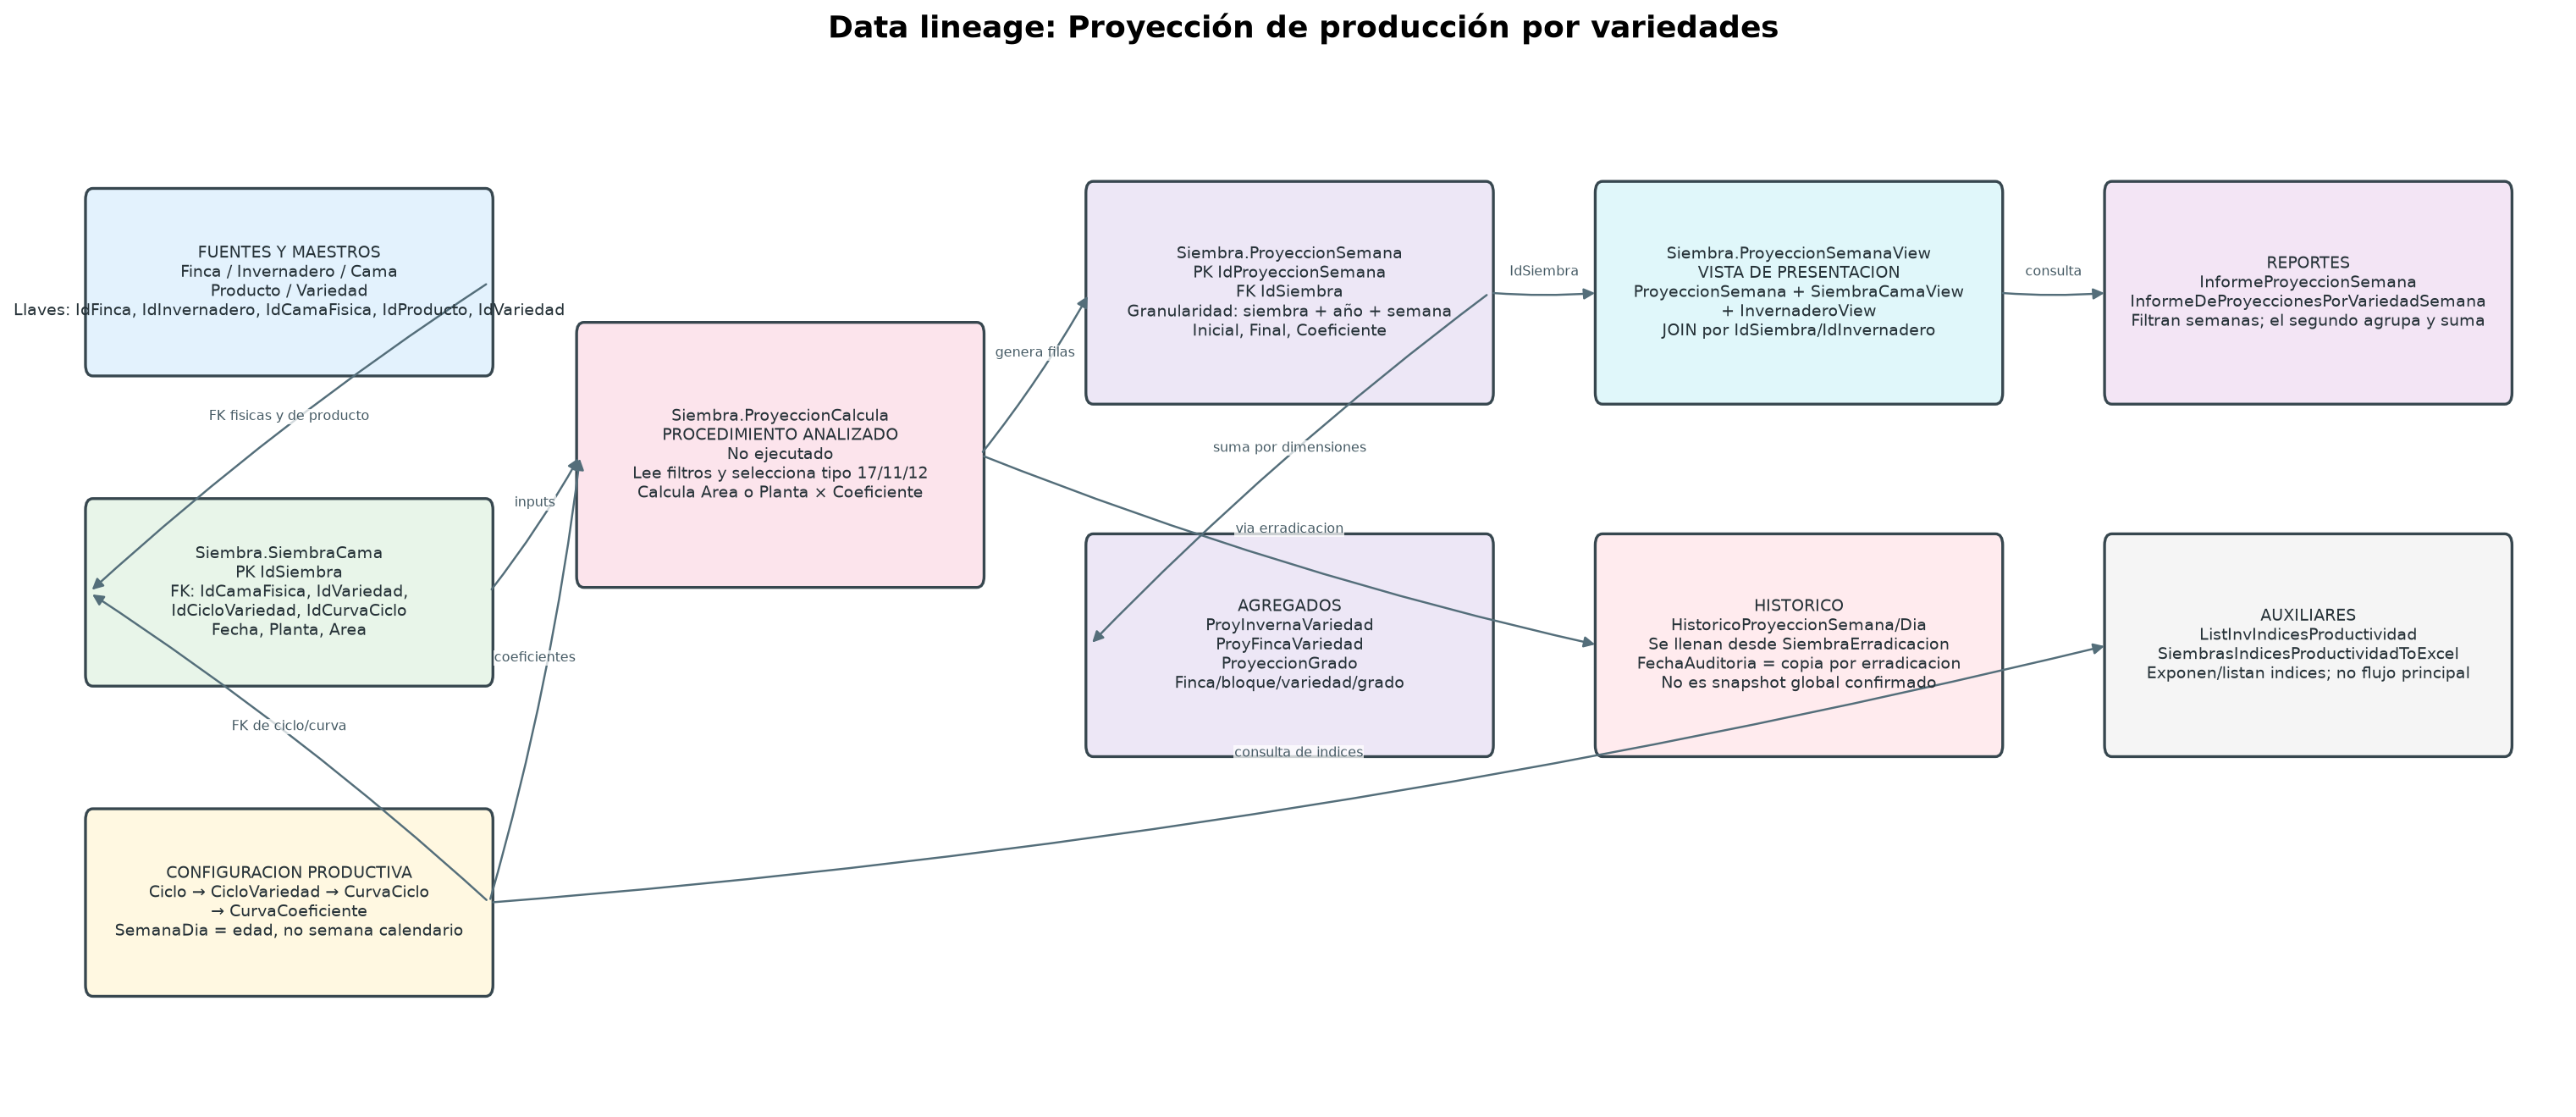

Mermaid exportado en: C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Notebooks\Extracción SQL\diagrama_proyeccion_variedades.mmd
Imagen PNG exportada en: C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Notebooks\Extracción SQL\diagrama_proyeccion_variedades.png


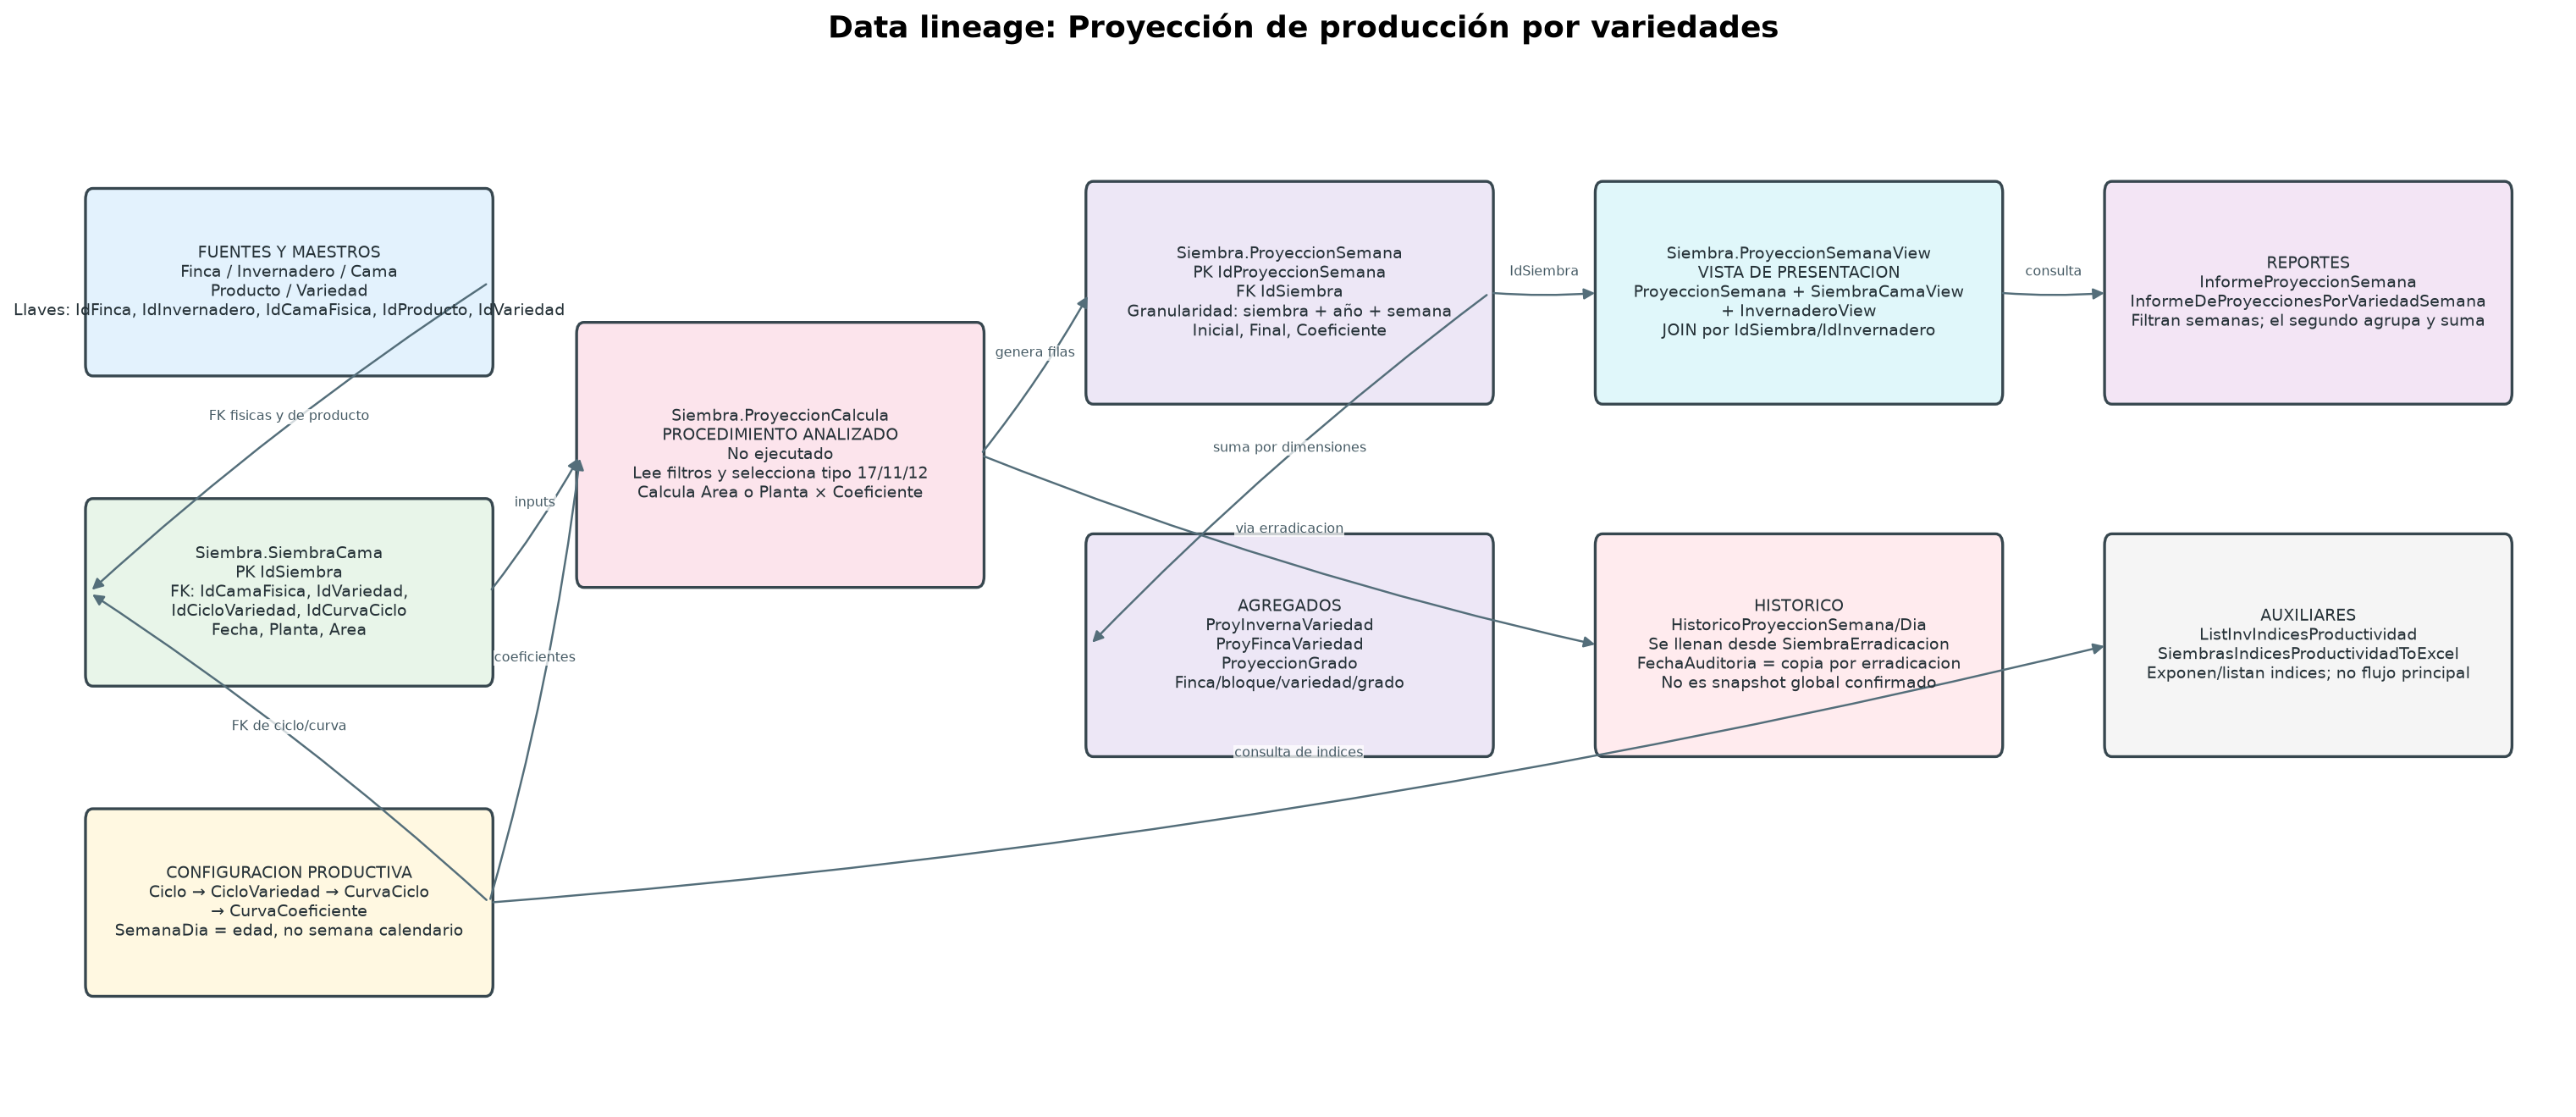

In [9]:
# Exportación de la fuente Mermaid y generación de una imagen PNG local.
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

CARPETA_TRABAJO = Path.cwd()
if not (CARPETA_TRABAJO / 'contexto_sql_gaitana_codex.txt').exists():
    CARPETA_TRABAJO = Path('Notebooks') / 'Extracción SQL'
CARPETA_TRABAJO.mkdir(parents=True, exist_ok=True)
ruta_mermaid = CARPETA_TRABAJO / 'diagrama_proyeccion_variedades.mmd'
mermaid_raw = mermaid.removeprefix('```mermaid\n').removesuffix('\n```')
ruta_mermaid.write_text(mermaid_raw, encoding='utf-8')

nodos = {
    'fuentes': (0, 5.2, 4.4, 1.25, '#e3f2fd', 'FUENTES Y MAESTROS\nFinca / Invernadero / Cama\nProducto / Variedad\nLlaves: IdFinca, IdInvernadero, IdCamaFisica, IdProducto, IdVariedad'),
    'siembra': (0, 3.0, 4.4, 1.25, '#e8f5e9', 'Siembra.SiembraCama\nPK IdSiembra\nFK: IdCamaFisica, IdVariedad,\nIdCicloVariedad, IdCurvaCiclo\nFecha, Planta, Area'),
    'config': (0, 0.8, 4.4, 1.25, '#fff8e1', 'CONFIGURACION PRODUCTIVA\nCiclo → CicloVariedad → CurvaCiclo\n→ CurvaCoeficiente\nSemanaDia = edad, no semana calendario'),
    'metodo': (5.4, 3.7, 4.4, 1.8, '#fce4ec', 'Siembra.ProyeccionCalcula\nPROCEDIMIENTO ANALIZADO\nNo ejecutado\nLee filtros y selecciona tipo 17/11/12\nCalcula Area o Planta × Coeficiente'),
    'base': (11.0, 5.0, 4.4, 1.5, '#ede7f6', 'Siembra.ProyeccionSemana\nPK IdProyeccionSemana\nFK IdSiembra\nGranularidad: siembra + año + semana\nInicial, Final, Coeficiente'),
    'agregados': (11.0, 2.5, 4.4, 1.5, '#ede7f6', 'AGREGADOS\nProyInvernaVariedad\nProyFincaVariedad\nProyeccionGrado\nFinca/bloque/variedad/grado'),
    'vista': (16.6, 5.0, 4.4, 1.5, '#e0f7fa', 'Siembra.ProyeccionSemanaView\nVISTA DE PRESENTACION\nProyeccionSemana + SiembraCamaView\n+ InvernaderoView\nJOIN por IdSiembra/IdInvernadero'),
    'informe': (22.2, 5.0, 4.4, 1.5, '#f3e5f5', 'REPORTES\nInformeProyeccionSemana\nInformeDeProyeccionesPorVariedadSemana\nFiltran semanas; el segundo agrupa y suma'),
    'historico': (16.6, 2.5, 4.4, 1.5, '#ffebee', 'HISTORICO\nHistoricoProyeccionSemana/Dia\nSe llenan desde SiembraErradicacion\nFechaAuditoria = copia por erradicacion\nNo es snapshot global confirmado'),
    'auxiliar': (22.2, 2.5, 4.4, 1.5, '#f5f5f5', 'AUXILIARES\nListInvIndicesProductividad\nSiembrasIndicesProductividadToExcel\nExponen/listan indices; no flujo principal'),
}
conexiones = [
    ('fuentes', 'siembra', 'FK fisicas y de producto'),
    ('config', 'siembra', 'FK de ciclo/curva'),
    ('siembra', 'metodo', 'inputs'),
    ('config', 'metodo', 'coeficientes'),
    ('metodo', 'base', 'genera filas'),
    ('base', 'vista', 'IdSiembra'),
    ('vista', 'informe', 'consulta'),
    ('base', 'agregados', 'suma por dimensiones'),
    ('metodo', 'historico', 'via erradicacion'),
    ('config', 'auxiliar', 'consulta de indices'),
]

fig, ax = plt.subplots(figsize=(24, 10), dpi=160)
ax.set_xlim(-0.5, 27.2); ax.set_ylim(0, 7.4); ax.axis('off')
centros = {}
for clave, (x, y, w, h, color, texto) in nodos.items():
    caja = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.04,rounding_size=0.08', linewidth=1.5, edgecolor='#37474f', facecolor=color)
    ax.add_patch(caja)
    ax.text(x + w/2, y + h/2, texto, ha='center', va='center', fontsize=8.5, color='#263238')
    centros[clave] = (x, y, w, h)
for origen, destino, etiqueta in conexiones:
    x1, y1, w1, h1 = centros[origen]; x2, y2, w2, h2 = centros[destino]
    inicio = (x1 + w1, y1 + h1/2) if x2 >= x1 else (x1, y1 + h1/2)
    fin = (x2, y2 + h2/2) if x2 >= x1 else (x2 + w2, y2 + h2/2)
    ax.add_patch(FancyArrowPatch(inicio, fin, arrowstyle='-|>', mutation_scale=12, linewidth=1.1, color='#546e7a', connectionstyle='arc3,rad=0.04'))
    ax.text((inicio[0]+fin[0])/2, (inicio[1]+fin[1])/2 + 0.10, etiqueta, fontsize=7, ha='center', va='bottom', color='#455a64', bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.5))
ax.set_title('Data lineage: Proyección de producción por variedades', fontsize=16, weight='bold', pad=12)
ruta_imagen = CARPETA_TRABAJO / 'diagrama_proyeccion_variedades.png'
fig.savefig(ruta_imagen, bbox_inches='tight', facecolor='white')
display(fig)
print('Mermaid exportado en:', ruta_mermaid.resolve())
print('Imagen PNG exportada en:', ruta_imagen.resolve())

## Cómo interpretar cada conexión del Mermaid

### A. Ubicación física de la siembra

- `Basico.Finca → Mapa.Invernadero`: la FK `Mapa.Invernadero.IdFinca → Basico.Finca.IdFinca` indica que un invernadero pertenece a una finca. Se necesita para reportar la proyección por finca.
- `Mapa.Invernadero → Mapa.CamaFisica`: la FK `CamaFisica.IdInvernadero → Invernadero.IdInvernadero` ubica cada cama dentro de un bloque. Se necesita porque la siembra se registra sobre una cama física, no directamente sobre la finca.
- `Mapa.CamaFisica → Siembra.SiembraCama`: la FK `SiembraCama.IdCamaFisica → CamaFisica.IdCamaFisica` conecta el lugar físico con la unidad productiva que se proyecta.

### B. Producto, variedad y configuración agronómica

- `Producto → Variedad`: `Variedad.IdProducto → Producto.IdProducto` permite pasar de la familia comercial al cultivar concreto.
- `Variedad → SiembraCama`: `SiembraCama.IdVariedad → Variedad.IdVariedad` identifica la variedad de cada siembra.
- `Ciclo → CicloVariedad`: `CicloVariedad.IdCiclo → Ciclo.IdCiclo` lleva a la parametrización general, incluyendo `PickPeriodo`, `PickForma` y `PickTipoProyeccion`.
- `Finca + Variedad + Ciclo → CicloVariedad`: las tres FKs explican por qué una misma variedad puede tener una configuración distinta por finca.
- `CicloVariedad → CurvaCiclo → CurvaCoeficiente`: estas FKs llevan desde la configuración de la variedad hasta el coeficiente por edad. `SemanaDia` no es semana calendario: es edad desde la siembra.

### C. Construcción del resultado

- `SiembraCama → ProyeccionCalcula`: es un flujo lógico, no una FK. El procedimiento lee ubicación, variedad, ciclo, curva, fecha de siembra, plantas y área para construir la proyección.
- `CurvaCoeficiente → ProyeccionCalcula`: aplica el método tipo 17 por edad. Para `PickForma = 44` usa área; para otras formas usa plantas; el contexto previo documenta redondeo a cero decimales.
- `CicloVariCoefInverna` y `CicloVariCoefFinca` son caminos alternativos: tipo 11 usa coeficiente por invernadero y tipo 12 por finca. Las líneas están separadas para no afirmar que los tres métodos se usan simultáneamente.
- `ProyeccionCalcula → ProyeccionSemana`: el resultado base queda a granularidad `IdSiembra + AnioProyeccion + SemanaProyeccion`. La FK confirmada es `ProyeccionSemana.IdSiembra → SiembraCama.IdSiembra`.

### D. Del resultado al informe

- `ProyeccionSemana → ProyeccionSemanaView`: la vista toma los valores calculados y los combina con `SiembraCamaView` e `InvernaderoView` mediante `IdSiembra` e `IdInvernadero`. Se hace para presentar nombres y dimensiones sin repetir el cálculo.
- `ProyeccionSemanaView → Reporte.InformeProyeccionSemana`: el procedimiento filtra por año y rango de semanas y devuelve el detalle por siembra.
- `ProyeccionSemanaView → Reporte.InformeDeProyeccionesPorVariedadSemana`: el procedimiento convierte las fechas a semanas y agrupa/suma por finca, invernadero, producto, variedad y semana.
- `Informe → Excel`: se representa como relación discontinua porque la exportación pertenece a la capa de WebFlor; no se confirmó que el procedimiento SQL genere directamente el archivo.

### E. Histórico y productividad

- `SiembraErradicacion → HistoricoProyeccionSemana/Dia`: la definición SQL confirma que copia las proyecciones de una siembra antes de eliminarlas. Por eso el histórico permite conservar información de siembras erradicadas, pero no es automáticamente un versionado global de cada forecast.
- `PorcentajeGrado → ProyeccionGrado`: se dibuja como relación candidata porque la tabla existe y tiene la misma dimensión finca/variedad/grado/semana, pero la participación exacta debe demostrarse en el código del cálculo.
- `ListInvIndicesProductividad` y `SiembrasIndicesProductividadToExcel`: son objetos auxiliares para listar/exponer índices. Se muestran fuera de la línea principal para no afirmar que el botón de índices sea el generador de proyecciones.

### Cardinalidades principales confirmadas

| Relación | Cardinalidad conceptual | Llave de unión | Razón |
|---|---:|---|---|
| Finca → Invernadero | 1 : N | `IdFinca` | Un bloque pertenece a una finca |
| Invernadero → CamaFisica | 1 : N | `IdInvernadero` | Un bloque contiene camas |
| CamaFisica → SiembraCama | 1 : N histórica | `IdCamaFisica` | Una cama puede tener siembras en el tiempo |
| Producto → Variedad | 1 : N | `IdProducto` | Una familia tiene varios cultivares |
| CicloVariedad → CurvaCiclo | 1 : N | `IdCicloVariedad` | Puede haber más de una curva configurada |
| CurvaCiclo → CurvaCoeficiente | 1 : N | `IdCurvaCiclo` | Una curva tiene puntos por edad |
| SiembraCama → ProyeccionSemana | 1 : N | `IdSiembra` | Una siembra tiene muchas semanas objetivo |

La cardinalidad `CamaFisica → SiembraCama` es conceptual/histórica: no significa que una cama tenga varias siembras activas simultáneamente. La consulta de datos debe validar estados y fechas antes de agregar.

## 9. Consultas finales y estado de evidencia

### Consultas read-only disponibles

1. Índices: `SELECT TOP (...) * FROM Siembra.CicloVariCoefInverna`, `Siembra.CicloVariCoefFinca` y `Siembra.CurvaCoeficiente`.
2. Inputs: `q_inputs`.
3. Resultado base: `Siembra.ProyeccionSemanaView` o `Siembra.ProyeccionSemana`.
4. Rango de semanas: agregar `WHERE AnioProyeccion = ? AND SemanaProyeccion BETWEEN ? AND ?`.
5. Finca/producto/variedad: agregar `IdFinca`, `IdProducto` e `IdVariedad`.
6. Informe: `Reporte.InformeProyeccionSemana`/`InformeDeProyeccionesPorVariedadSemana` fueron analizados, pero no ejecutados.
7. Histórico: `q_historico_resumen` y `q_historico_muestra`.
8. Generaciones: no se confirmó `IdEjecucion`/versión; `FechaAuditoria` del histórico identifica el momento de copia por erradicación.
9. Comparación de una semana entre generaciones: pendiente porque no hay snapshot global por ejecución confirmado.
10. Última proyección: `q_ultima_muestra` y `QUERY_DESCARGA_ULTIMA_PROYECCION`.
11. Descarga completa: ejecutar la celda de extracción; exporta CSV localmente sin modificar SQL Server.

### HECHOS CONFIRMADOS

- El informe semanal lee `Siembra.ProyeccionSemanaView`.
- La vista une `ProyeccionSemana`, `SiembraCamaView` e `InvernaderoView`.
- `ProyeccionCalcula` recibe rango de semanas y filtros de compañía/finca/invernadero/variedad; su definición contiene operaciones destructivas y no fue ejecutado.
- Hay históricos de semana/día, pero se llenan en `SiembraErradicacion`.
- La tabla actual contiene 310.580 filas y la muestra real está incluida arriba.

### HIPÓTESIS / PENDIENTES

- `FechaAuditoria` de `ProyeccionSemana` no equivale necesariamente a fecha de generación global.
- No se confirmó que el botón funcional se llame físicamente igual en SQL.
- No se confirmó un snapshot completo por cada ejecución de proyección.
- La exportación a Excel depende de la aplicación; los procedimientos `ToExcel` de índices no son el informe semanal.